:::{canonical-tutorial} tutorials/basics/clustering
:::

# Preprocessing and clustering

##기본세팅

In [1]:
!pip install anndata
!pip install scanpy

# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc

In [2]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

/tmp/ipykernel_1305/2889020069.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=50, facecolor="white")


##데이터 불러오기

In [3]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [4]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

## Quality Control

In [5]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [6]:
#qc metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

plot 그려서 확인

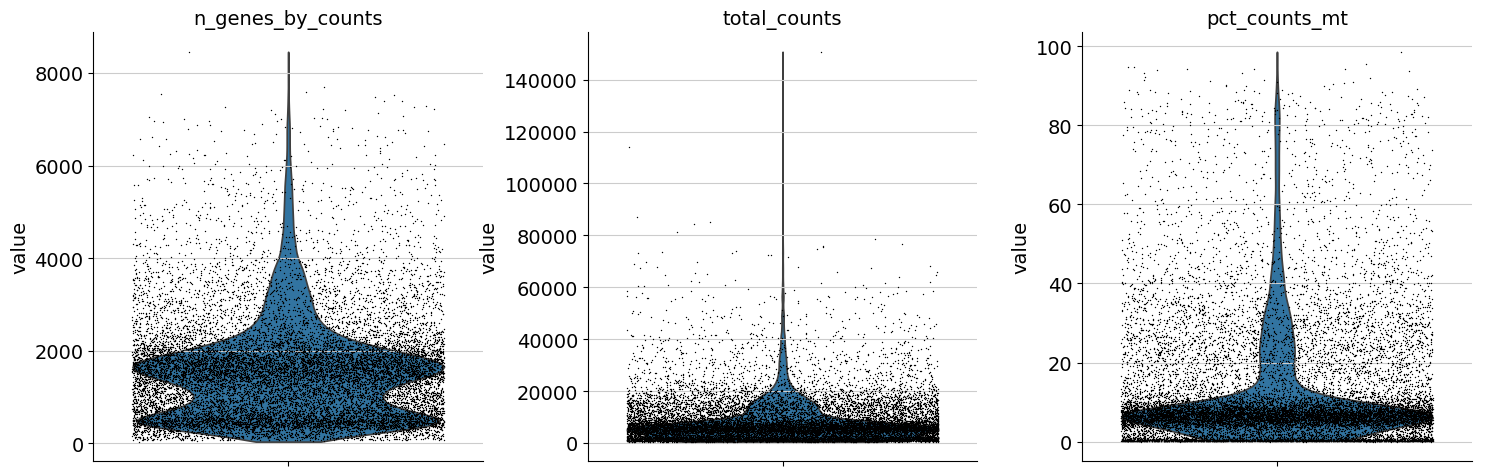

In [7]:
#violin plot
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

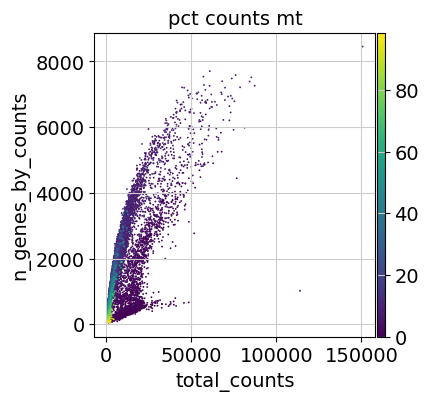

In [8]:
#scatter plot
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [10]:
#대략적인 필터링
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [11]:
#Doublet detection:cell 2개가 1개로 읽힌 경우
sc.pp.scrublet(adata, batch_key="sample")

We can remove doublets by either filtering out the cells called as doublets, or waiting until we've done a clustering pass and filtering out any clusters with high doublet scores.

## Normalization

In [12]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [13]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

## Feature selection


In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

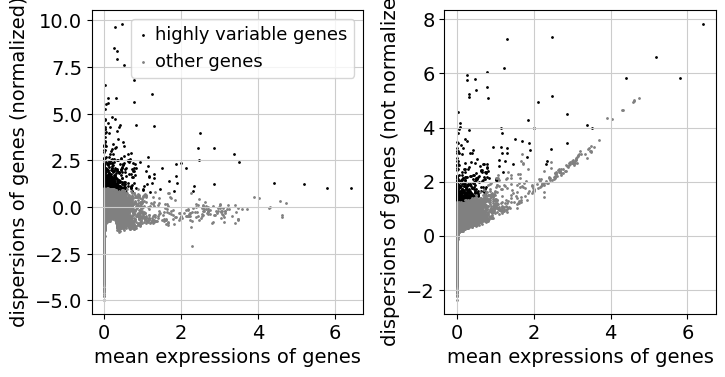

In [17]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction

In [18]:
sc.tl.pca(adata)

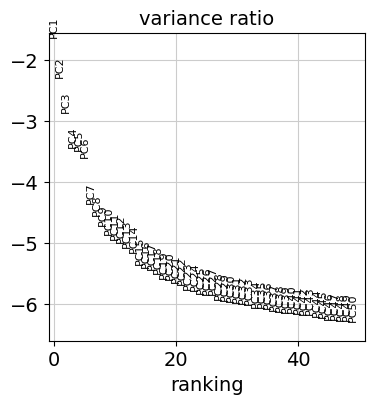

In [19]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

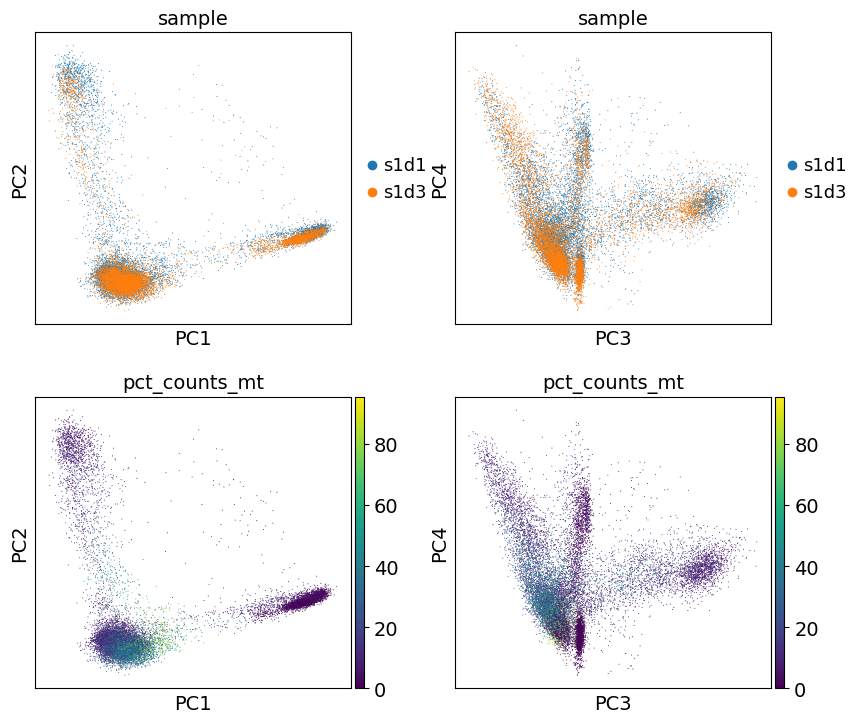

In [20]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## Nearest neighbor graph construction and visualization



In [21]:
sc.pp.neighbors(adata, random_state=0)

In [22]:
sc.tl.umap(adata, random_state=0)

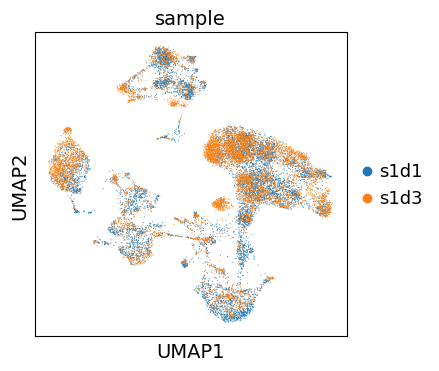

In [23]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

## Clustering


In [25]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
!pip install igraph
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.8 MB/s eta 0:00:00


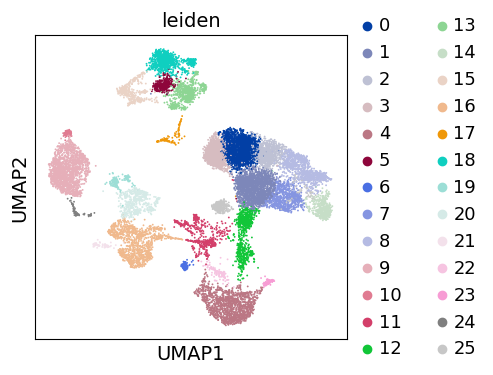

In [26]:
sc.pl.umap(adata, color=["leiden"])

```{dropdown} How do I save a plot?
You can save a plot by directly accessing the returned Matplotlib figure:
````python
sc.pl.umap(adata, color=["leiden"], show).figure.savefig("output_path.ext")
````
```

## Re-assess quality control and cell filtering

As indicated before, we will now re-assess our filtering strategy by visualizing different QC metrics using UMAP.

특정 클러스터가 품질이 좋지 않은 세포들로 주로 구성되어 있는지 확인

-> 여기서는 clustser단위로는 정상이기 때문에 cluster 제거 안 함

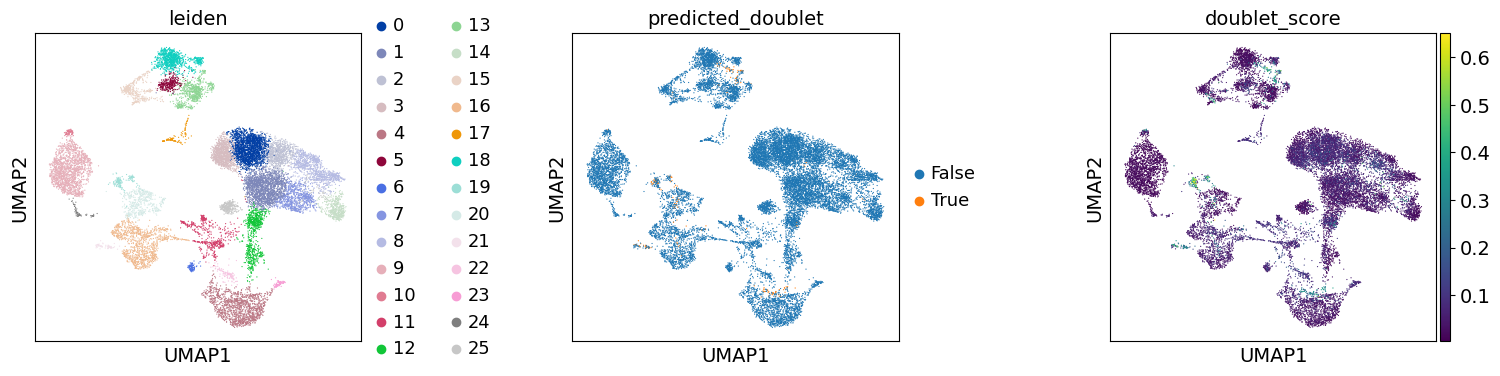

In [27]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

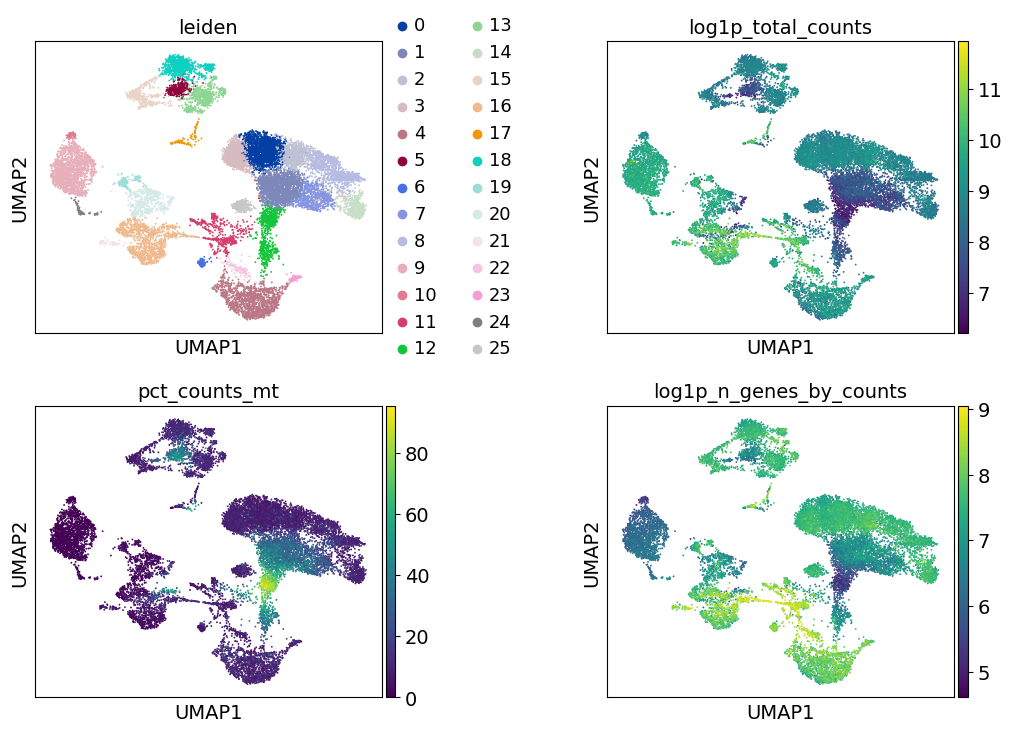

In [28]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Manual cell-type annotation

collected and curated various marker genes into available resources, such as [CellMarker](http://bio-bigdata.hrbmu.edu.cn/CellMarker/), [TF-Marker](http://bio.liclab.net/TF-Marker/), and [PanglaoDB](https://panglaodb.se/), [cellxgene gene expression tool](https://cellxgene.cziscience.com/gene-expression)

In [30]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

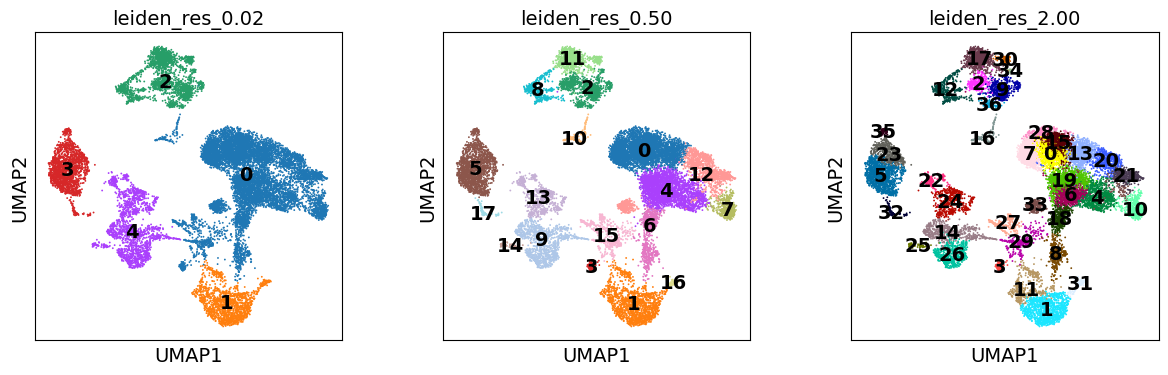

In [31]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

### Marker gene set : marker -> DEG 체크

 [Single Cell Best Practices annotation chapter](https://www.sc-best-practices.org/cellular_structure/annotation.html)

In [32]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

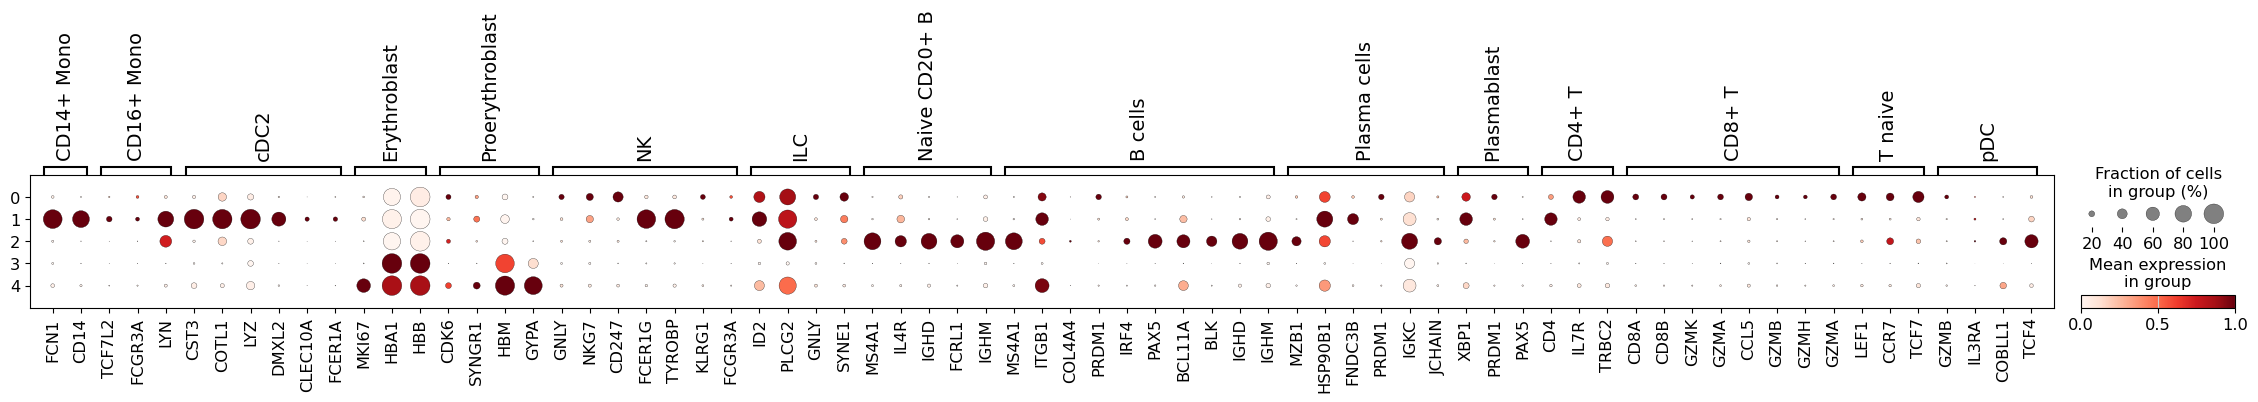

In [33]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var")

In [34]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "Lymphocytes",
        "1": "Monocytes",
        "2": "Erythroid",
        "3": "B Cells",
    }
)

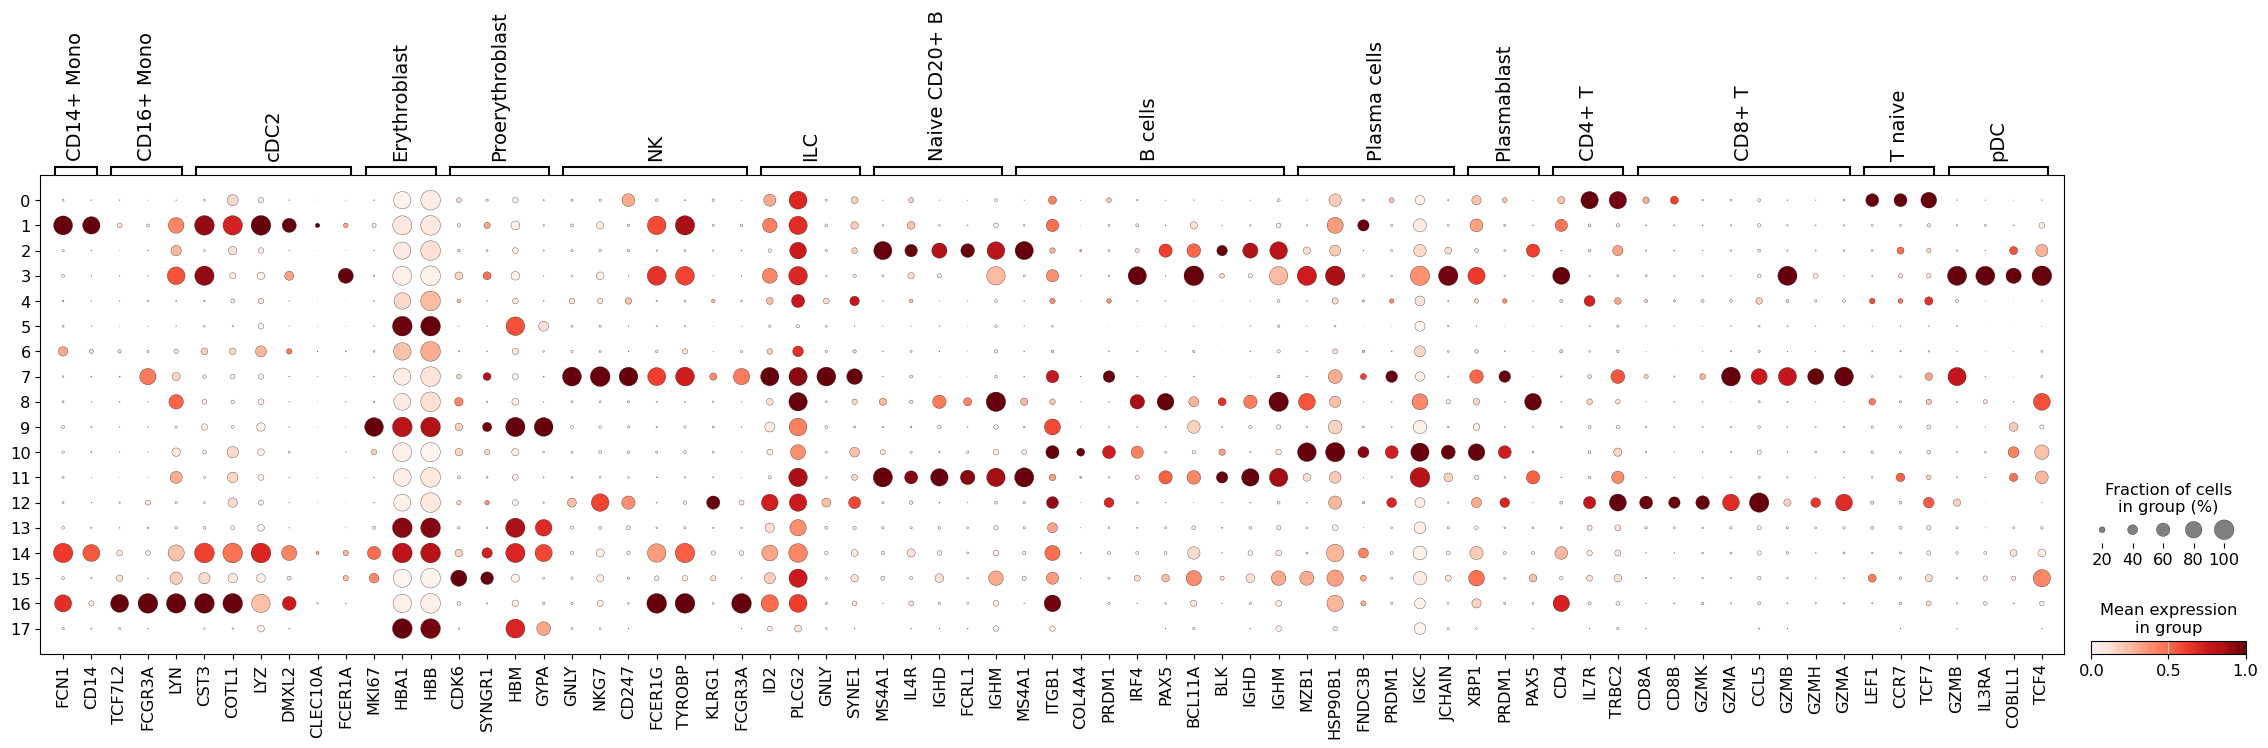

In [35]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

This seems like a resolution that suitable to distinguish most of the different cell types in our data. As such, let's try to annotate those by manually using the dotplot above, together with the UMAP of our clusters. Ideally, one would also look specifically into each cluster, and attempt to subcluster those if required.

### Differentially-expressed Genes as Markers : DEG->marker확인

In [36]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

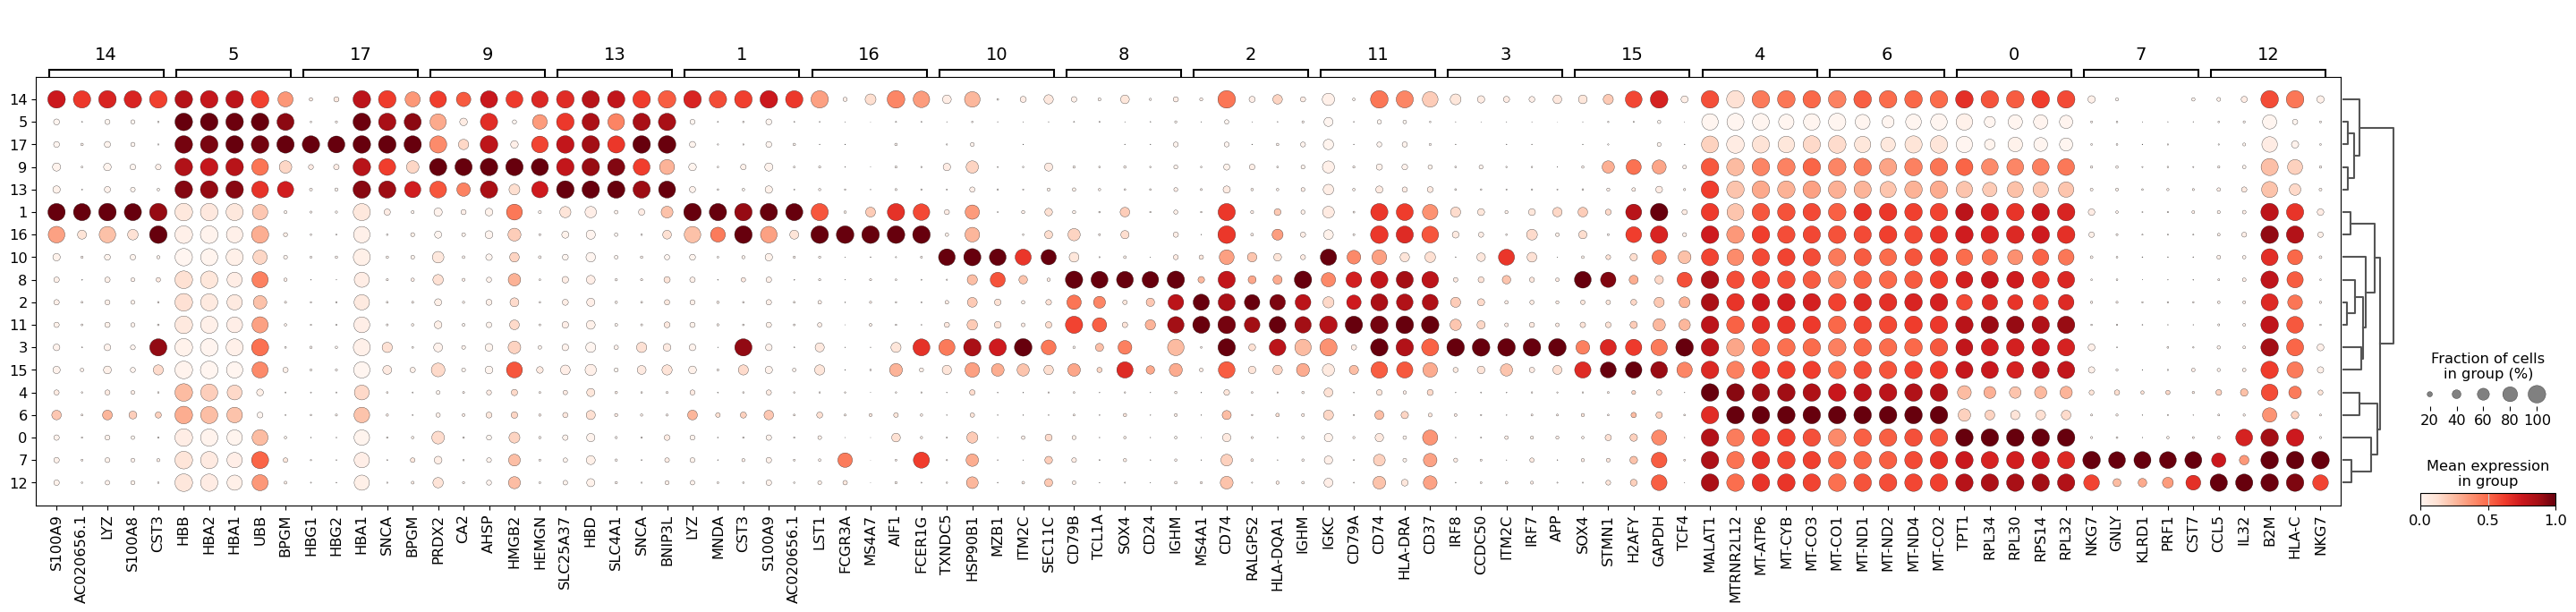

In [38]:
#visualization
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5)

We can then use these genes to figure out what cell types we're looking at. For example, Cluster 7 is expressing [*NKG7*](https://www.genecards.org/cgi-bin/carddisp.pl?gene=NKG7&keywords=nkg7) and [*GNLY*](https://www.genecards.org/cgi-bin/carddisp.pl?gene=GNLY&keywords=GNLY), suggesting these are [NK cells](https://en.wikipedia.org/wiki/Natural_killer_cell).

In [39]:
sc.get.rank_genes_groups_df(adata, group="7").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,NKG7,35.537918,6.548978,1.277051e-276,2.991748e-272
1,GNLY,33.851448,7.374753,3.455431e-251,4.047519e-247
2,KLRD1,33.814442,5.832656,1.209767e-250,9.447073e-247
3,PRF1,33.023769,5.431675,3.703158e-239,2.168847e-235
4,CST7,33.007786,5.233107,6.280117e-239,2.942486e-235


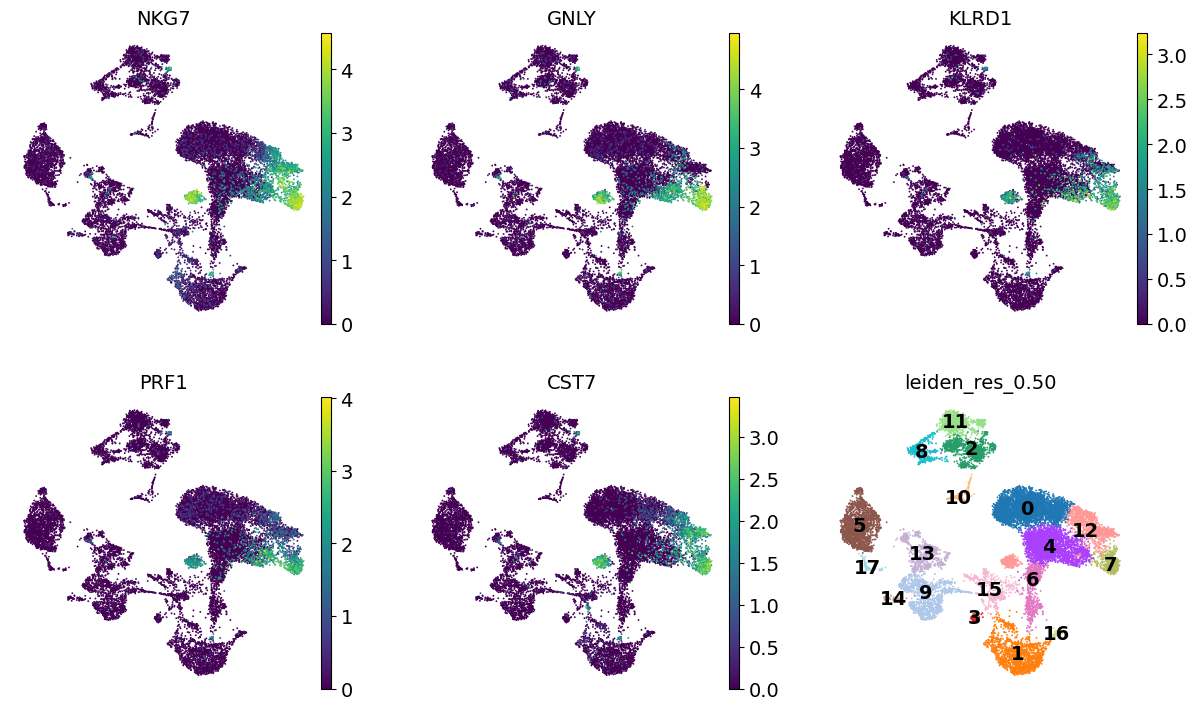

In [40]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)